In [ ]:
import os
import numpy as np
import jax
import jax.numpy as jnp
from omegaconf import OmegaConf

import jaxmarl
from plotter import RolloutPlotter, plot_action_stats

### Load Agent: IPPO

In [2]:
from ippo_rnn_road_env import load_checkpoint_agent, ScannedRNN, batchify, unbatchify

checkpoint_path = "../outputs/ToyExample-v2/ippo_rnn/2025-04-27_19-51-23.915589"
step = 1485
vmapped_seed = 0

config = OmegaConf.load(os.path.join(checkpoint_path, "config.yaml"))
config = OmegaConf.to_container(config)

network, params, _ = load_checkpoint_agent(checkpoint_path, step, vmapped_seed, config)

In [3]:
NUM_TIMESTEPS = 50
NUM_ENVS = 1

# Initialise environment
config["ENV_KWARGS"]["return_infos"] = True
env = jaxmarl.make(config["ENV_NAME"], **config["ENV_KWARGS"])

NUM_ACTORS = NUM_ENVS * env.num_agents

rp = RolloutPlotter(env)

In [ ]:
key = jax.random.PRNGKey(87)

# initialise RNN state and dones
hstate = ScannedRNN.initialize_carry(NUM_ACTORS, config["GRU_HIDDEN_DIM"])
dones_batch = jnp.zeros((NUM_ACTORS,), dtype=jnp.bool_)

key, key_reset = jax.random.split(key, 2)
obs, env_state = env.reset(key_reset)

episode_data = rp.get_episode_data_stencil()

episode_cost = 0

episode_data["edge_states"].append(env_state.damage_state)
episode_data["edge_observations"].append(env_state.observation)
episode_data["edge_beliefs"].append(env_state.belief)
episode_data["budget_remaining"].append(env_state.budget_remaining)

# ToDo: implement rollout using lax.scan
for t in range(NUM_TIMESTEPS):

    # SELECT ACTION
    key, key_actions = jax.random.split(key, 2)
    obs_batch = batchify(obs, env.agents, NUM_ACTORS)
    ac_in = (obs_batch[np.newaxis, :], dones_batch[np.newaxis, :])
    hstate, pi, _ = network.apply(params, hstate, ac_in)
    action = pi.sample(seed=key_actions)
    env_act = unbatchify(action, env.agents, NUM_ENVS, env.num_agents)
    env_act = {k: v.squeeze() for k, v in env_act.items()}

    # STEP ENV
    key, key_step = jax.random.split(key, 2)
    obs, env_state, rewards, dones, infos = env.step(key_step, env_state, env_act)
    dones_batch = batchify(dones, env.agents, NUM_ACTORS).squeeze()

    episode_cost += rewards["__all__"]

    # UPDATE EPISODE DATA
    # deterioration
    episode_data["edge_states"].append(env_state.damage_state)
    episode_data["edge_observations"].append(env_state.observation)
    episode_data["edge_beliefs"].append(env_state.belief)

    # actions
    episode_data["action"].append(action)
    episode_data["applied_actions"].append(infos["applied_actions"])
    episode_data["forced_replace_constraint_applied"].append(infos["forced_replace_constraint_applied"])
    
    # traffic
    episode_data["total_travel_time"].append(infos["total_travel_time"])
    # episode_data["travel_times"].append(infos["travel_times"]) # ToDo: return in info from jax env
    # episode_data["traffic_volumes"].append(infos["traffic_volumes"]) # ToDo: return in info from jax env

    # budget
    episode_data["budget_remaining"].append(env_state.budget_remaining)
    episode_data["budget_constraints_applied"].append(infos["budget_constraints_applied"])
    
    # rewards
    episode_data["reward"].append(rewards["__all__"])
    episode_data["travel_time_reward"].append(infos["reward_elements"]["travel_time_reward"])
    episode_data["maintenance_reward"].append(infos["reward_elements"]["maintenance_reward"])
    episode_data["terminal_reward"].append(infos["reward_elements"]["terminal_reward"])

episode_data["episode_cost"] = episode_cost

In [5]:
plot_data = rp._preprocess_episode_data(episode_data)

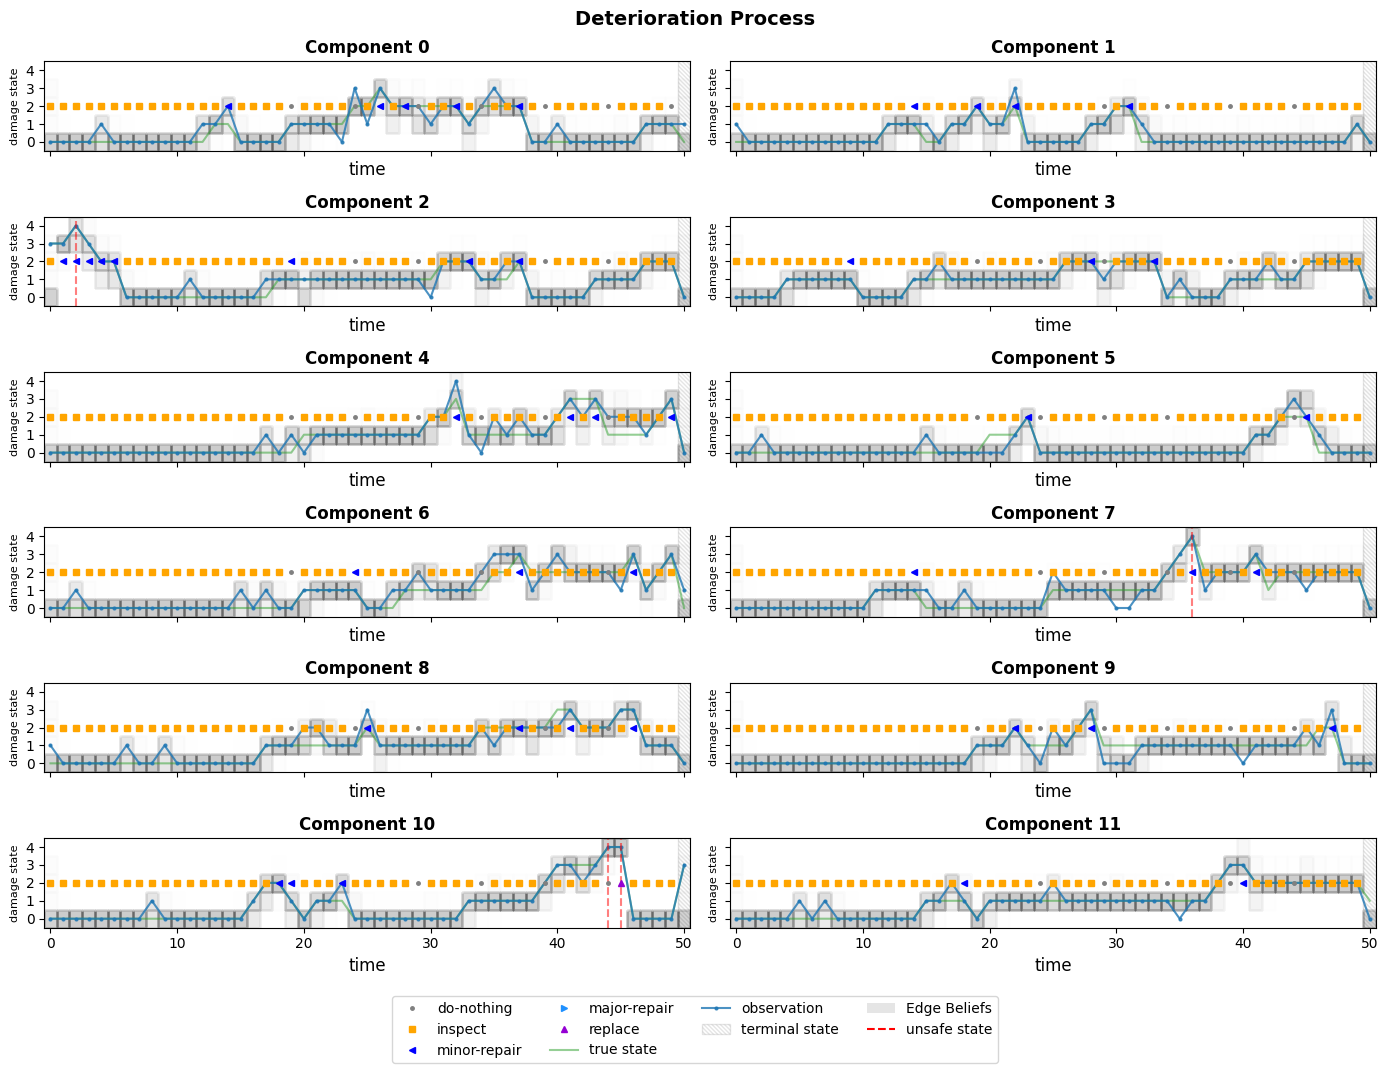

In [6]:
rp._plot_deterioration(plot_data)

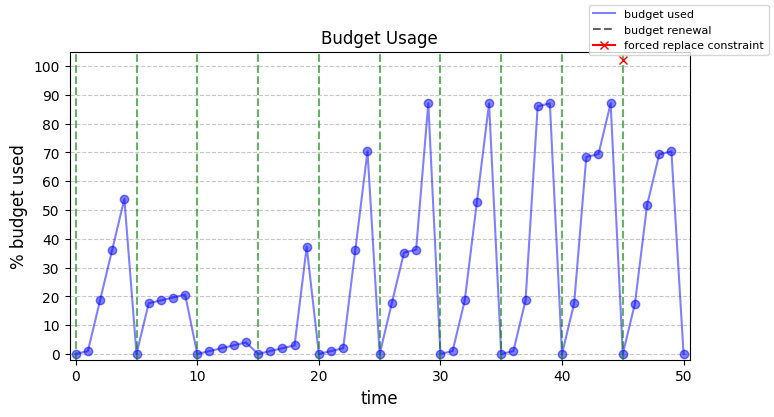

In [7]:
rp._plot_budget(plot_data)

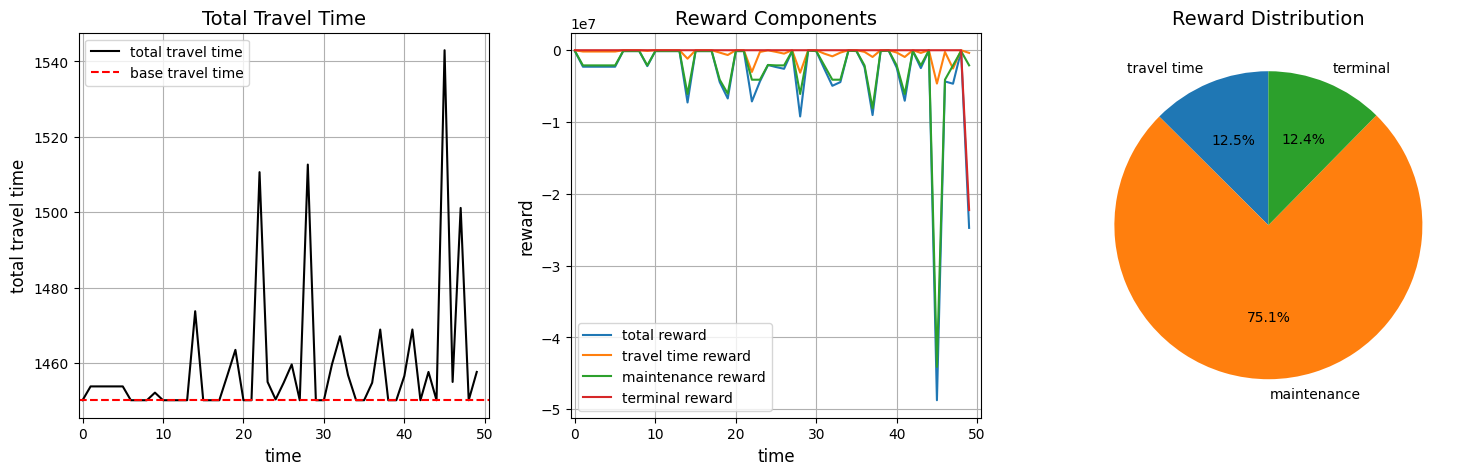

In [8]:
rp._plot_travel_time_and_rewards(plot_data)

IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

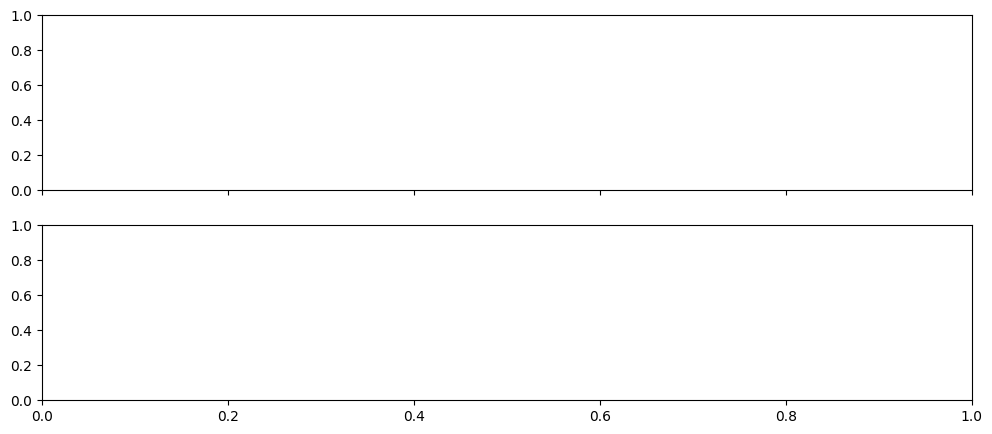

In [11]:
# ToDo: return travel times and traffic volumes in info from jax env
rp._plot_traffic_volume_and_travel_times(plot_data)

### Action Stats

In [ ]:
key = jax.random.PRNGKey(1234)

# initialise RNN state and dones
hstate = ScannedRNN.initialize_carry(NUM_ACTORS, config["GRU_HIDDEN_DIM"])
dones_batch = jnp.zeros((NUM_ACTORS,), dtype=jnp.bool_)

key, key_reset = jax.random.split(key, 2)
obs, env_state = env.reset(key_reset)

episode_cost = 0

NUM_EPISODES = 100
action_stats_data = np.empty((NUM_EPISODES,  NUM_TIMESTEPS, env.num_agents), dtype=int)

# ToDo: implement rollout using lax.scan
for ep in range(NUM_EPISODES):

    for t in range(NUM_TIMESTEPS):

        # SELECT ACTION
        key, key_actions = jax.random.split(key, 2)
        obs_batch = batchify(obs, env.agents, NUM_ACTORS)
        ac_in = (obs_batch[np.newaxis, :], dones_batch[np.newaxis, :])
        hstate, pi, _ = network.apply(params, hstate, ac_in)
        action = pi.sample(seed=key_actions)
        env_act = unbatchify(action, env.agents, NUM_ENVS, env.num_agents)
        env_act = {k: v.squeeze() for k, v in env_act.items()}

        # STEP ENV
        key, key_step = jax.random.split(key, 2)
        obs, env_state, rewards, dones, infos = env.step(key_step, env_state, env_act)
        dones_batch = batchify(dones, env.agents, NUM_ACTORS).squeeze()

        episode_cost += rewards["__all__"]

        # UPDATE EPISODE DATA
        action_stats_data[ep, t] = infos["applied_actions"]

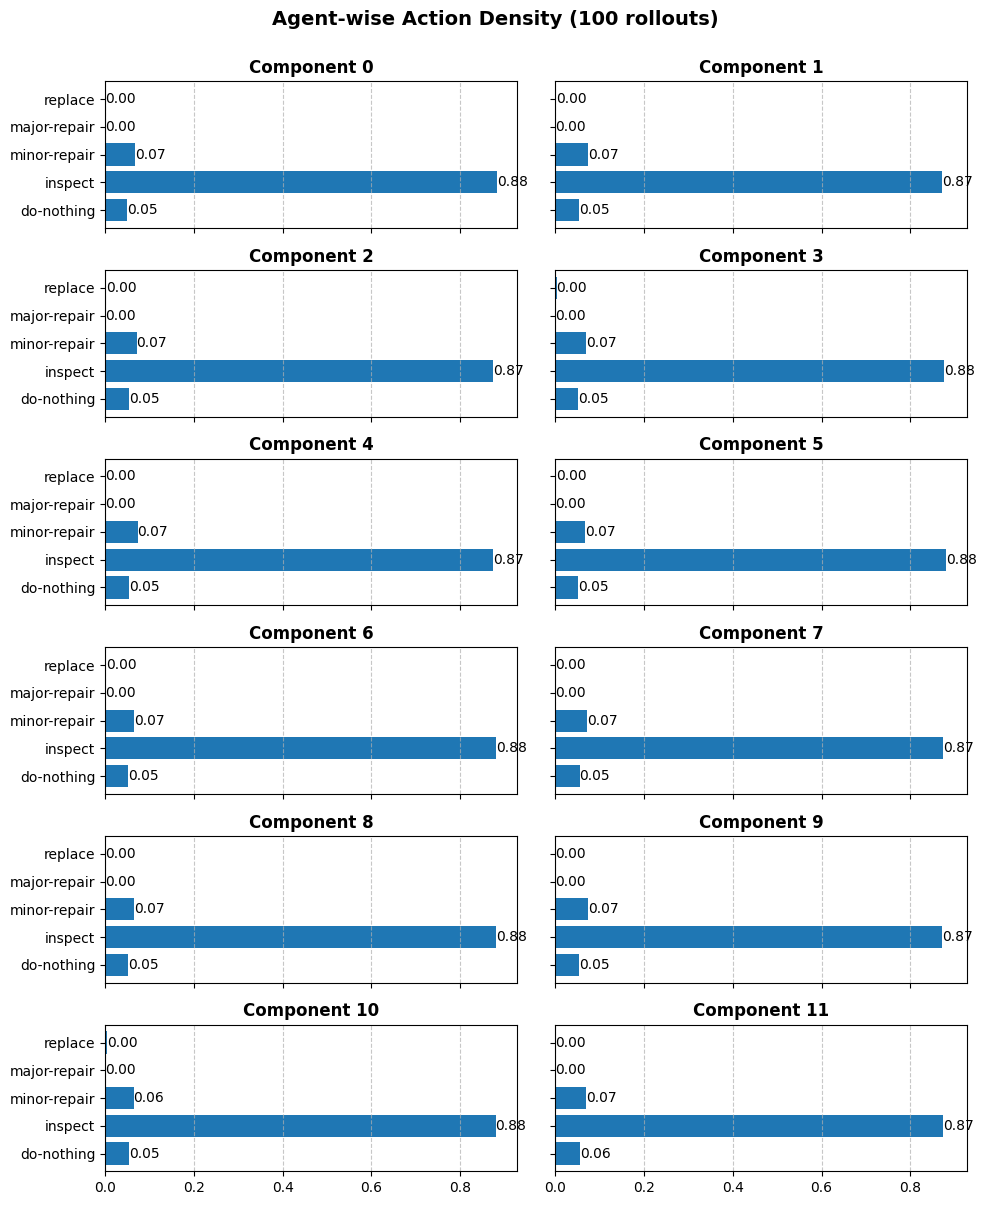

In [10]:
plot_action_stats(action_stats_data)